In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate


In [2]:
# Load coordinate and curvature data
x, y =   np.loadtxt('GMZ/down/RuO2-kslice-coord.dat', unpack=True)
zdown =  np.loadtxt('GMZ/down/RuO2-kslice-curv.dat', unpack=True)
zup =    np.loadtxt('GMZ/up/RuO2-kslice-curv.dat', unpack=True)

zmax = 200
zdown = np.where(zdown < zmax, zdown, 0)
zup = np.where(zup < zmax, zup, 0)
print(np.min(zdown), np.max(zdown))

# Calculate ranges for later use
x_range = x.max() - x.min()
y_range = y.max() - y.min()

# Define k-slice plane according to your specification:
# kslice_corner = 0.0 0.0 0.0        ! Gamma point (corner 1)
# kslice_b1 = 0.5 0.5 0.0            ! Direction to M point
# kslice_b2 = 0.0 0.0 0.5            ! Direction to A point (via Z)

# K-point coordinates in fractional coordinates
gamma_point = np.array([0.0, 0.0, 0.0])  # Γ point
M_point = np.array([0.5, 0.5, 0.0])      # M point  
A_point = np.array([0.0, 0.0, 0.5])      # A point

print(f"Data shape: x={len(x)}, y={len(y)}")
print(f"Berry curvature components: {len(zup)} (x, y, z components)")
print(f"X range: {x.min():.3f} to {x.max():.3f}")
print(f"Y range: {y.min():.3f} to {y.max():.3f}")
print(f"x_range = {x_range:.3f}, y_range = {y_range:.3f}")

-0.1846858 7.6263305
Data shape: x=9409, y=9409
Berry curvature components: 3 (x, y, z components)
X range: 0.000 to 0.979
Y range: 0.000 to 1.003
x_range = 0.979, y_range = 1.003


Global color range: min=-5.7941, max=7.6263
x-component range: min=-5.7941, max=7.6263
y-component range: min=-0.2895, max=7.6180
z-component range: min=-0.2236, max=0.9731


C:\Users\ASUS\AppData\Local\Temp\ipykernel_32396\3927385272.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


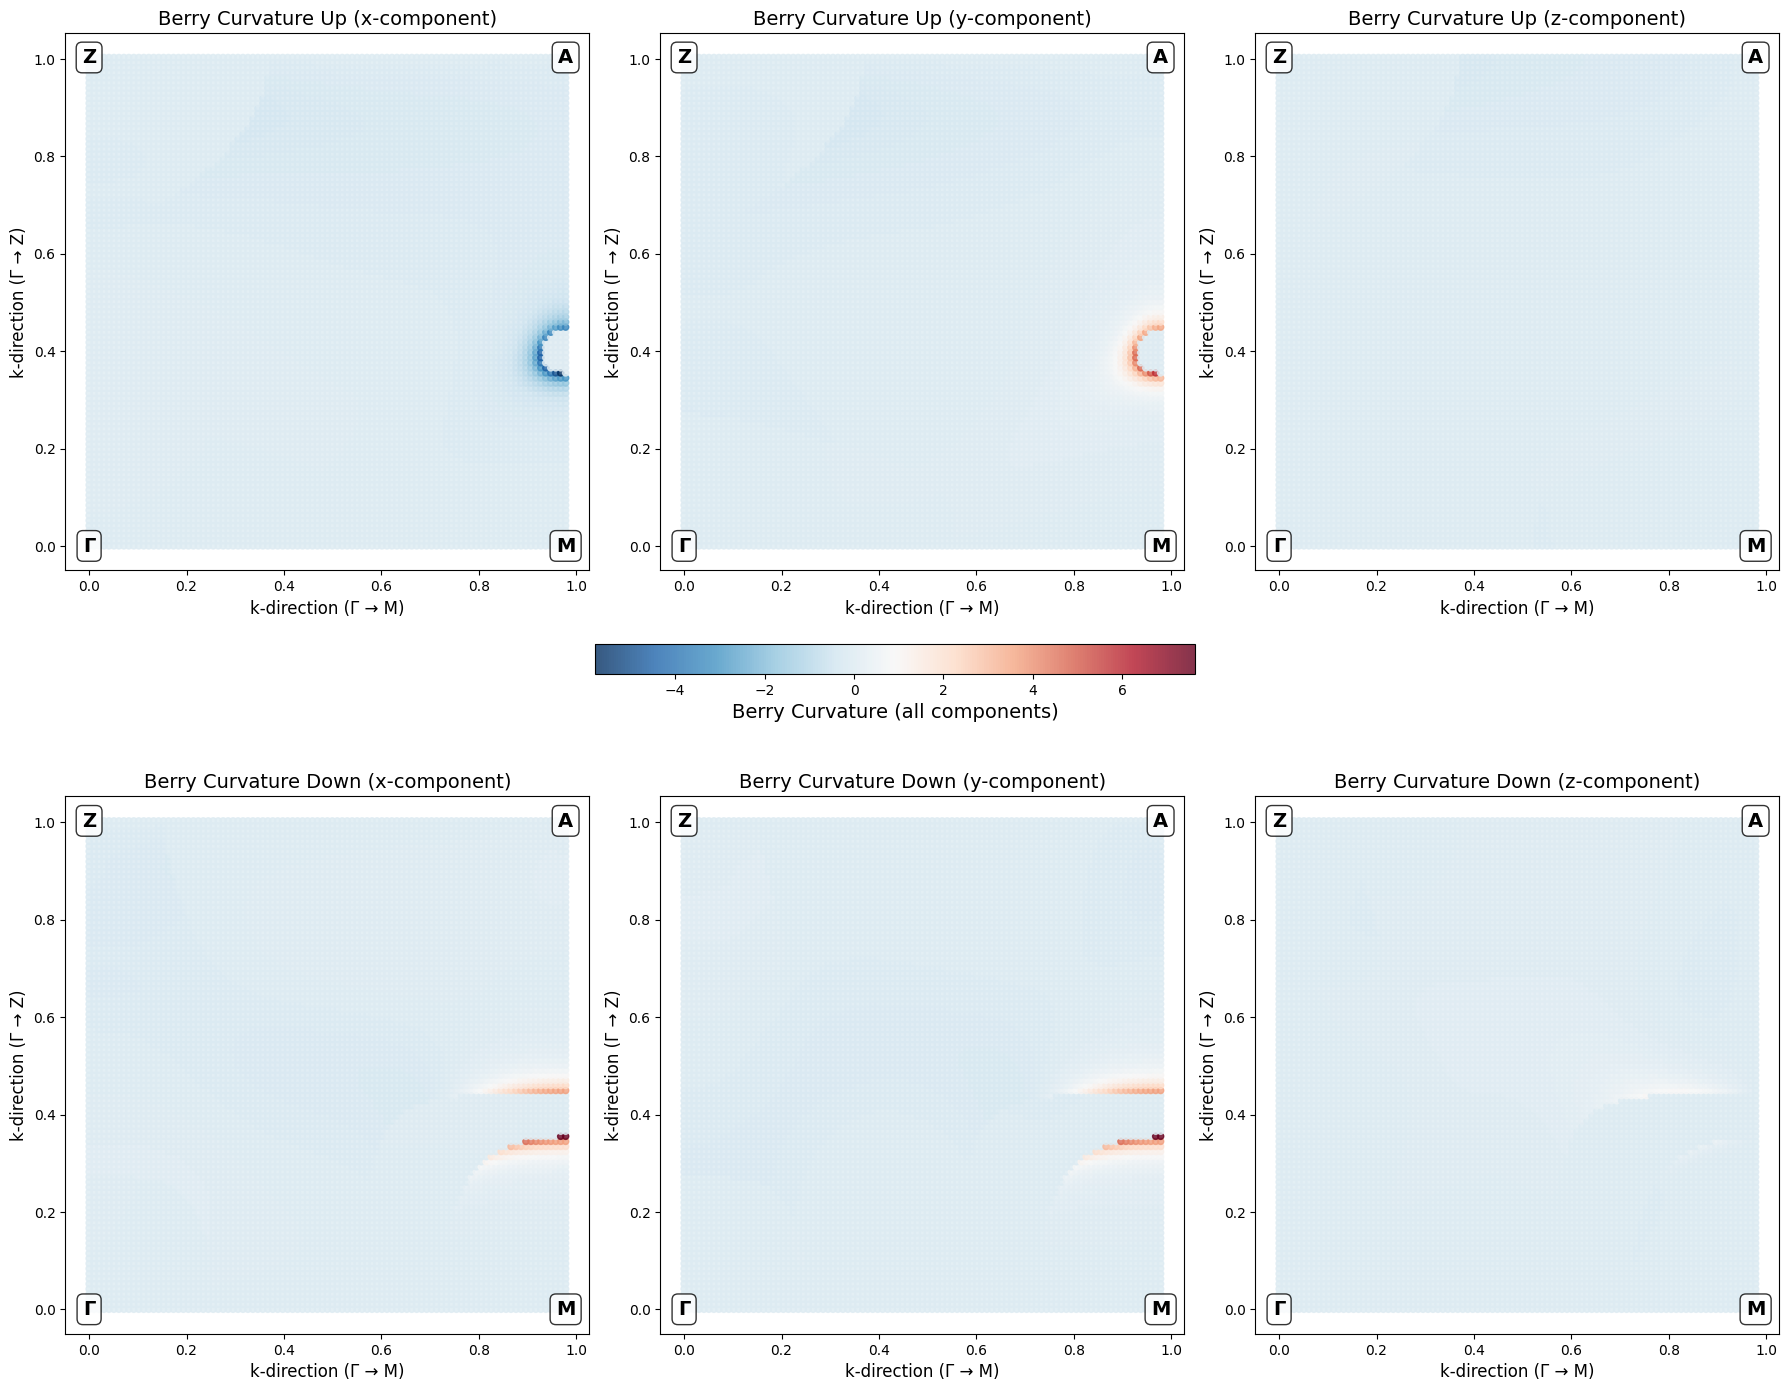

In [3]:
# Create figure with subplots for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(18, 15))

# Load bands data for Fermi lines (using the same data as the Berry curvature)
bands = np.loadtxt('GMZ/down/RuO2-kslice-bands.dat')
num_pt = len(x)
numbands = bands.size // num_pt
ef = 12.253400  # Fermi energy from the original scripts

# Prepare bands data for interpolation and contouring
bbands = bands.reshape((num_pt, numbands))

# Setup interpolation grid for Fermi lines
from collections import OrderedDict
points_x = np.around(x, decimals=10)
points_y = np.around(y, decimals=10)
area = 0.981404
xmin, ymin = np.min(points_x), np.min(points_y)
xmax, ymax = np.max(points_x), np.max(points_y)
a = np.max(np.array([xmax-xmin, ymax-ymin]))
num_int = int(round(np.sqrt(num_pt*a**2/area)))
xint = np.linspace(xmin, xmin+a, num_int)
yint = np.linspace(ymin, ymin+a, num_int)
grid_x, grid_y = np.meshgrid(xint, yint)
# Component names
components = ['x', 'y', 'z']

# Calculate global color range for ALL components (shared across x, y, z)
vmin_global = min(np.min(zup[0]), np.min(zup[1]), np.min(zup[2]), 
                  np.min(zdown[0]), np.min(zdown[1]), np.min(zdown[2]))
vmax_global = max(np.max(zup[0]), np.max(zup[1]), np.max(zup[2]), 
                  np.max(zdown[0]), np.max(zdown[1]), np.max(zdown[2]))

print(f'Global color range: min={vmin_global:.4f}, max={vmax_global:.4f}')

# Store scatter plot for colorbar reference
scatter_ref = None

for i, comp_name in enumerate(components):
    # Print individual component ranges for reference
    vmin_comp = min(np.min(zup[i]), np.min(zdown[i]))
    vmax_comp = max(np.max(zup[i]), np.max(zdown[i]))
    print(f'{comp_name}-component range: min={vmin_comp:.4f}, max={vmax_comp:.4f}')
    
    # Plot for up component (top row) - using global color scale
    scatter_up = axes[0, i].scatter(x, y, c=zup[i], cmap='RdBu_r', s=20, alpha=0.8, 
                                    vmin=vmin_global, vmax=vmax_global)
    axes[0, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[0, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[0, i].set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[0, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[0, i].tick_params(labelsize=10)
    axes[0, i].set_aspect('equal')

    # Plot for down component (bottom row) - using global color scale
    scatter_down = axes[1, i].scatter(x, y, c=zdown[i], cmap='RdBu_r', s=20, alpha=0.8,
                                      vmin=vmin_global, vmax=vmax_global)
    axes[1, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[1, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[1, i].set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[1, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[1, i].tick_params(labelsize=10)
    axes[1, i].set_aspect('equal')
    
    # Store reference for shared colorbar
    if scatter_ref is None:
        scatter_ref = scatter_up

# Add single shared horizontal colorbar below all subplots
cbar = fig.colorbar(scatter_ref, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.ax.set_position([0.25, 0.45, 0.5, 0.02])  # [left, bottom, width, height] in figure coordinates
cbar.set_label('Berry Curvature (all components)', fontsize=14)

plt.tight_layout()
plt.show()

In [4]:
# Load coordinate and curvature data
x, y =   np.loadtxt('GXZ/up/RuO2-kslice-coord.dat', unpack=True)
zdown =  np.loadtxt('GXZ/up/RuO2-kslice-curv.dat', unpack=True)
zup =    np.loadtxt('GXZ/down/RuO2-kslice-curv.dat', unpack=True)
print(np.min(zdown), np.max(zdown))

# Calculate ranges for later use
x_range = x.max() - x.min()
y_range = y.max() - y.min()

# Define k-slice plane according to your specification:
# kslice_corner = 0.0 0.0 0.0        ! Gamma point (corner 1)
# kslice_b1 = 0.5 0.5 0.0            ! Direction to M point
# kslice_b2 = 0.0 0.0 0.5            ! Direction to A point (via Z)

# K-point coordinates in fractional coordinates
gamma_point = np.array([0.0, 0.0, 0.0])  # Γ point
M_point = np.array([0.5, 0.5, 0.0])      # M point  
A_point = np.array([0.0, 0.0, 0.5])      # A point
print(max(zup[0]), max(zup[1]), max(zup[2]), max(zdown[0]), max(zdown[1]), max(zdown[2]))

-0.16813928 0.18132373
0.12882316 0.11744766 0.057054917 0.10753129 0.18132373 0.088827105


Global color range: min=-0.1681, max=0.1813
x-component range: min=-0.1034, max=0.1288
y-component range: min=-0.1166, max=0.1813
z-component range: min=-0.1681, max=0.0888


C:\Users\ASUS\AppData\Local\Temp\ipykernel_32396\2299088463.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


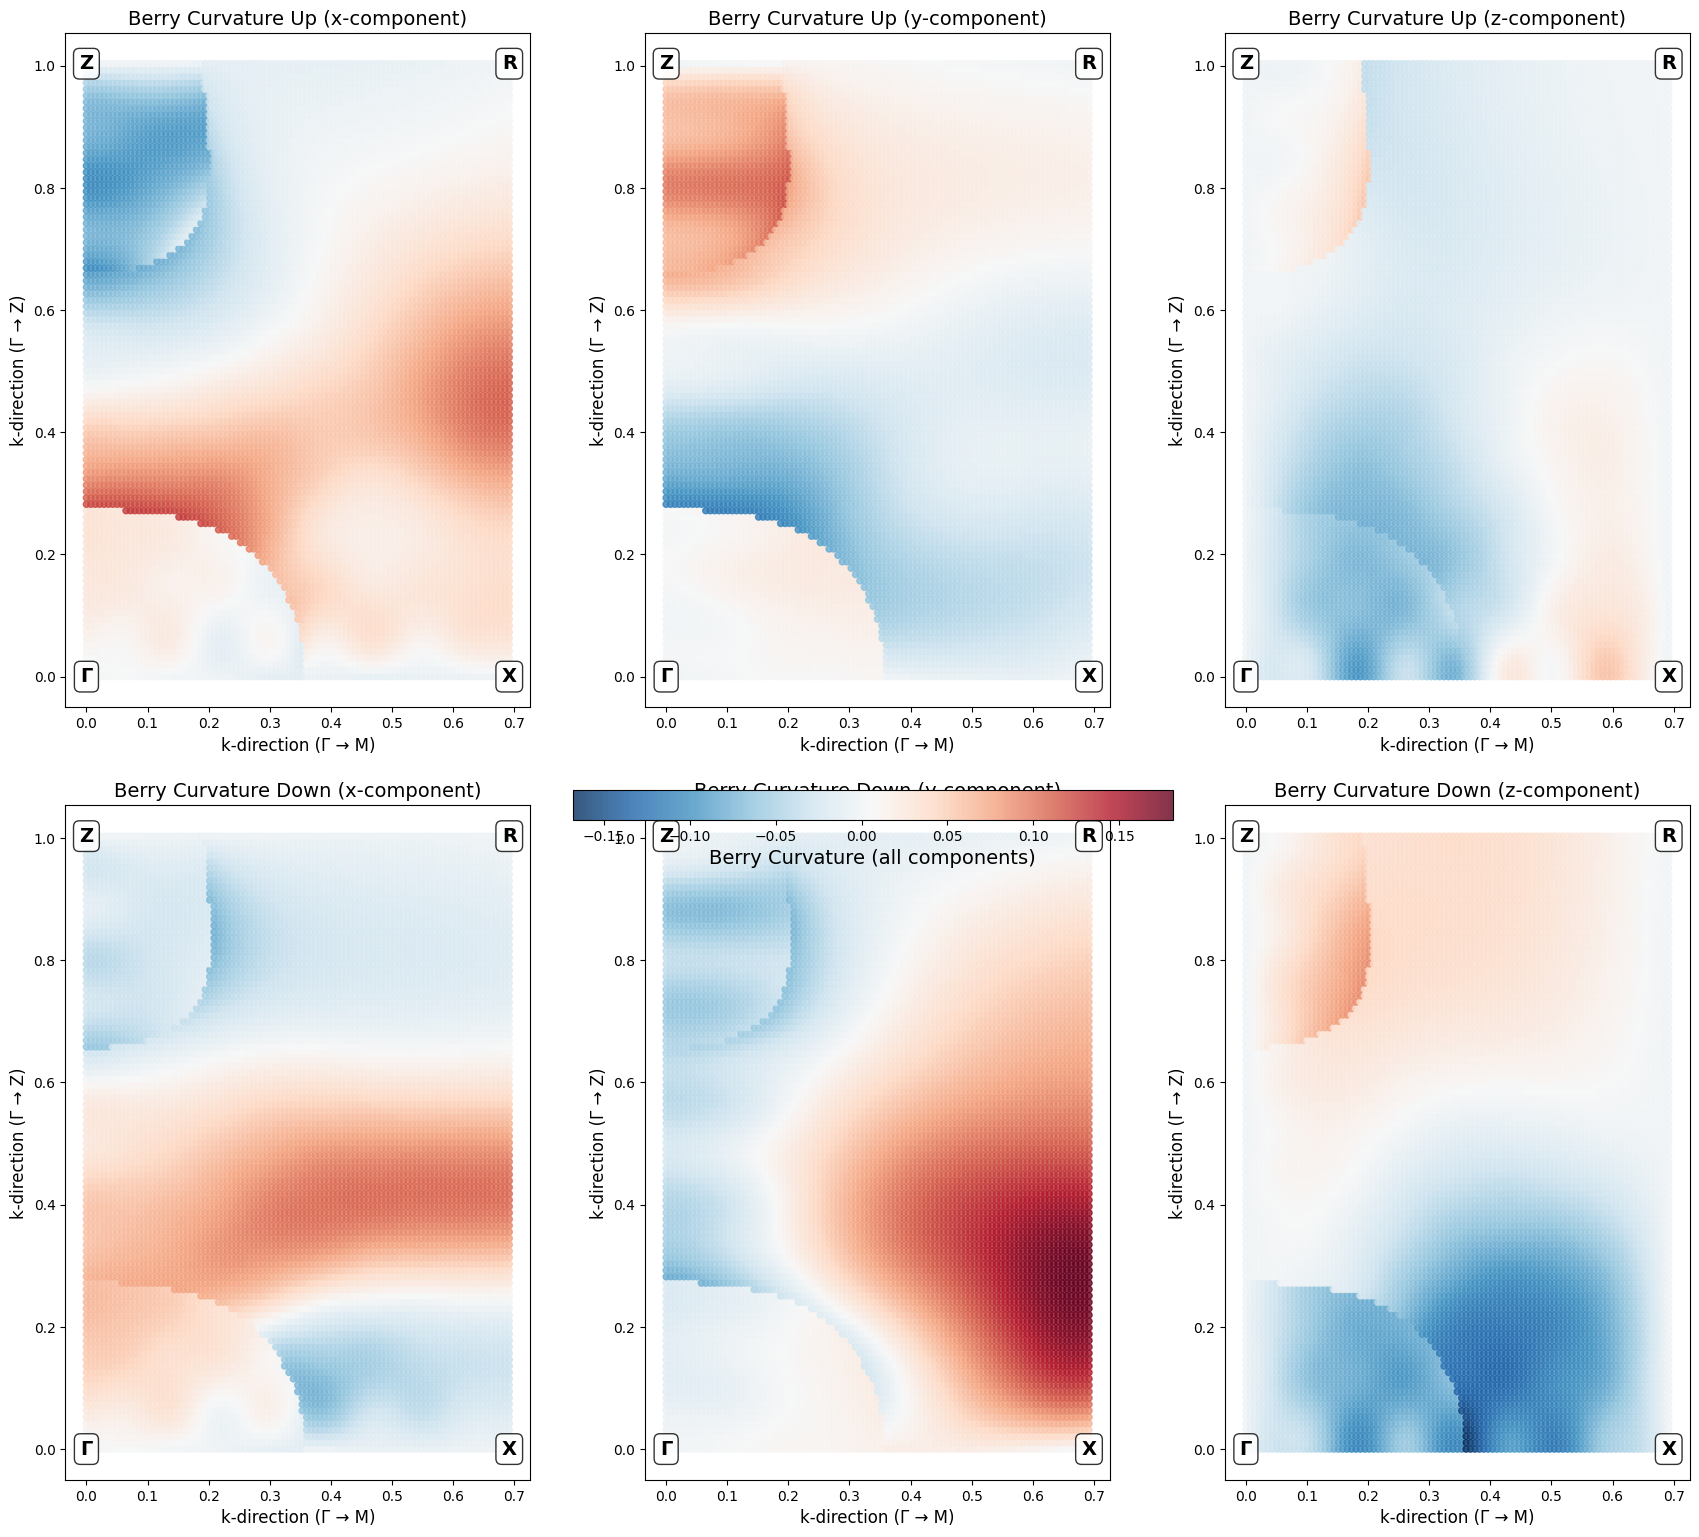

In [5]:
# Create figure with subplots for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(18, 15))

# Component names
components = ['x', 'y', 'z']

# Calculate global color range for ALL components (shared across x, y, z)
vmin_global = min(np.min(zup[0]), np.min(zup[1]), np.min(zup[2]), 
                  np.min(zdown[0]), np.min(zdown[1]), np.min(zdown[2]))
vmax_global = max(np.max(zup[0]), np.max(zup[1]), np.max(zup[2]), 
                  np.max(zdown[0]), np.max(zdown[1]), np.max(zdown[2]))

print(f'Global color range: min={vmin_global:.4f}, max={vmax_global:.4f}')

# Store scatter plot for colorbar reference
scatter_ref = None

for i, comp_name in enumerate(components):
    # Print individual component ranges for reference
    vmin_comp = min(np.min(zup[i]), np.min(zdown[i]))
    vmax_comp = max(np.max(zup[i]), np.max(zdown[i]))
    print(f'{comp_name}-component range: min={vmin_comp:.4f}, max={vmax_comp:.4f}')
    
    # Plot for up component (top row) - using global color scale
    scatter_up = axes[0, i].scatter(x, y, c=zup[i], cmap='RdBu_r', s=20, alpha=0.8, 
                                    vmin=vmin_global, vmax=vmax_global)
    axes[0, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[0, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[0, i].set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[0, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.min(), 'X', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.max(), 'R', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[0, i].tick_params(labelsize=10)
    axes[0, i].set_aspect('equal')

    # Plot for down component (bottom row) - using global color scale
    scatter_down = axes[1, i].scatter(x, y, c=zdown[i], cmap='RdBu_r', s=20, alpha=0.8,
                                      vmin=vmin_global, vmax=vmax_global)
    axes[1, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[1, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[1, i].set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[1, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.min(), 'X', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.max(), 'R', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[1, i].tick_params(labelsize=10)
    axes[1, i].set_aspect('equal')
    
    # Store reference for shared colorbar
    if scatter_ref is None:
        scatter_ref = scatter_up

# Add single shared horizontal colorbar below all subplots
cbar = fig.colorbar(scatter_ref, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.ax.set_position([0.25, 0.45, 0.5, 0.02])  # [left, bottom, width, height] in figure coordinates
cbar.set_label('Berry Curvature (all components)', fontsize=14)

plt.tight_layout()
plt.show()

Creating Berry curvature heatmaps with Fermi lines...


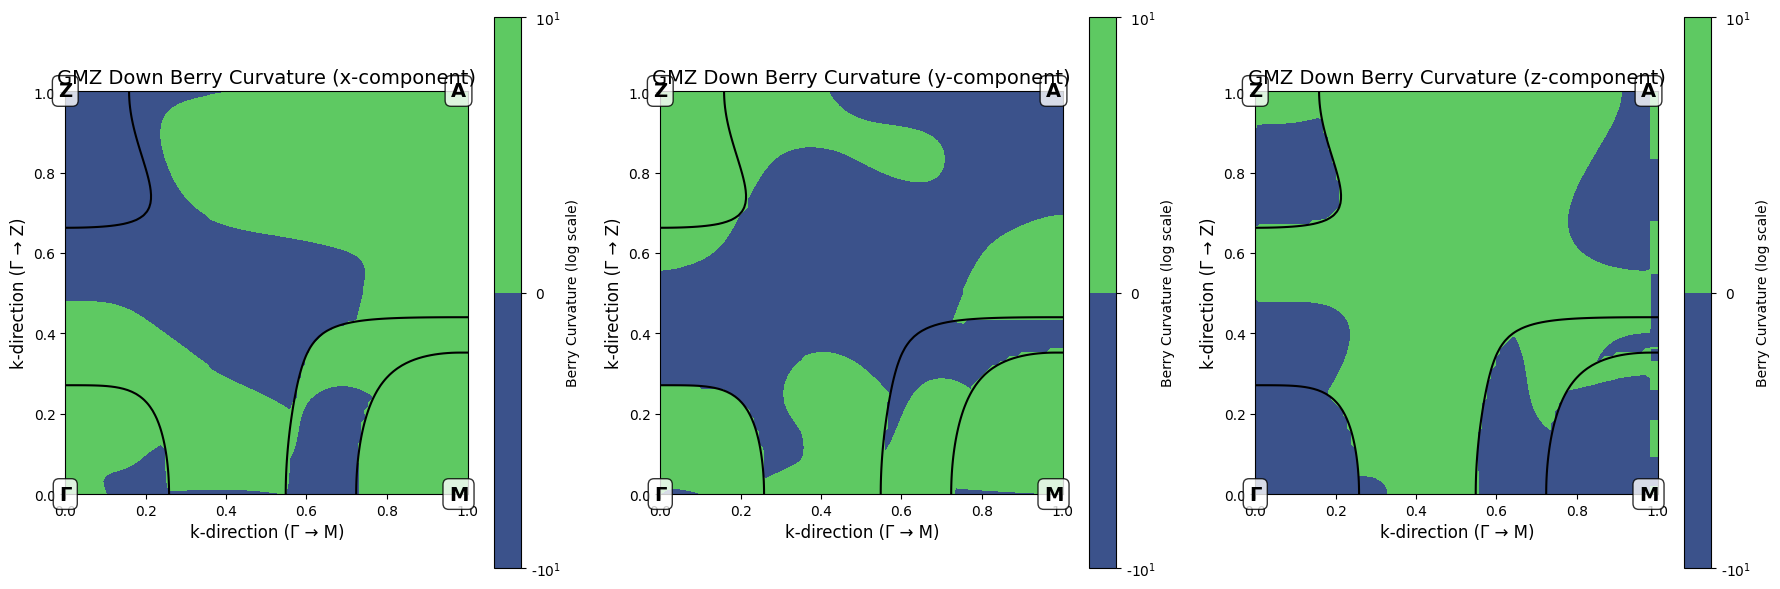

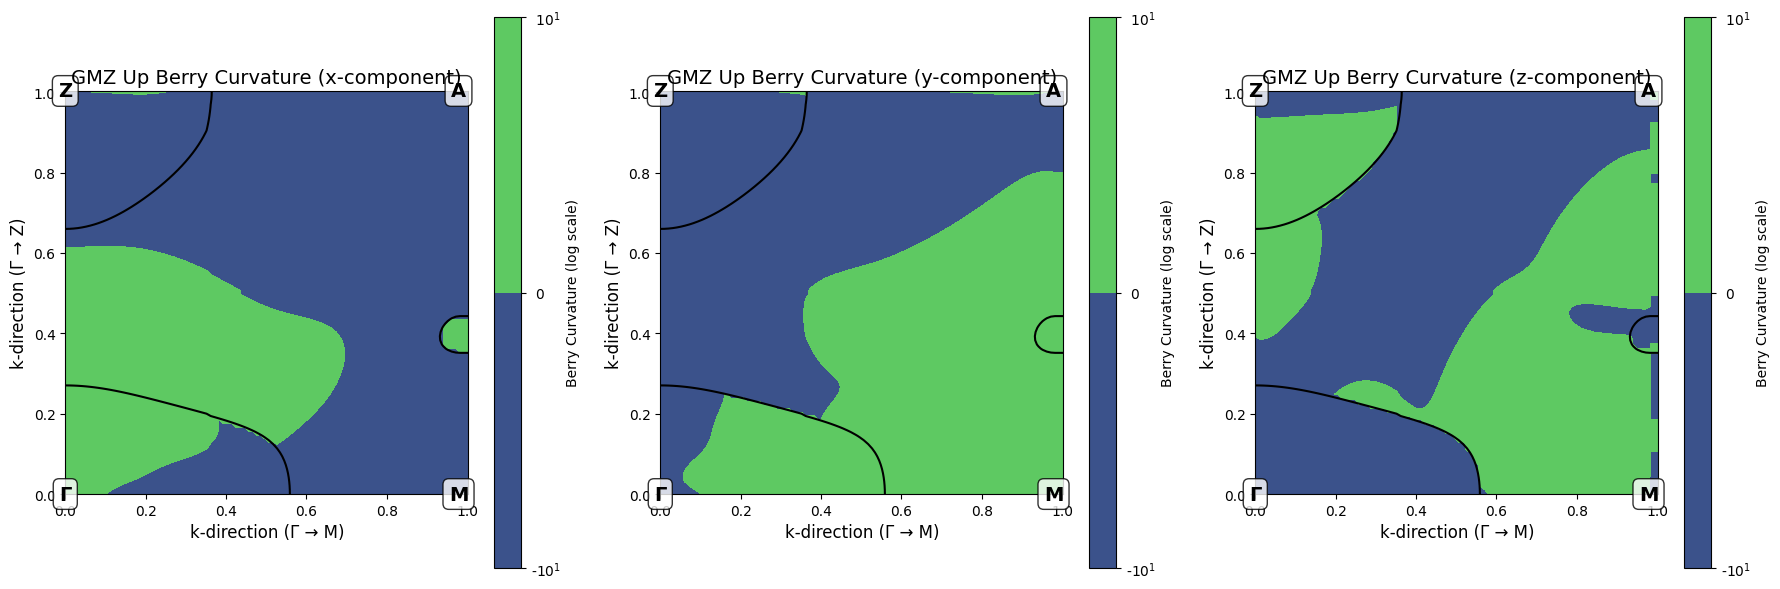

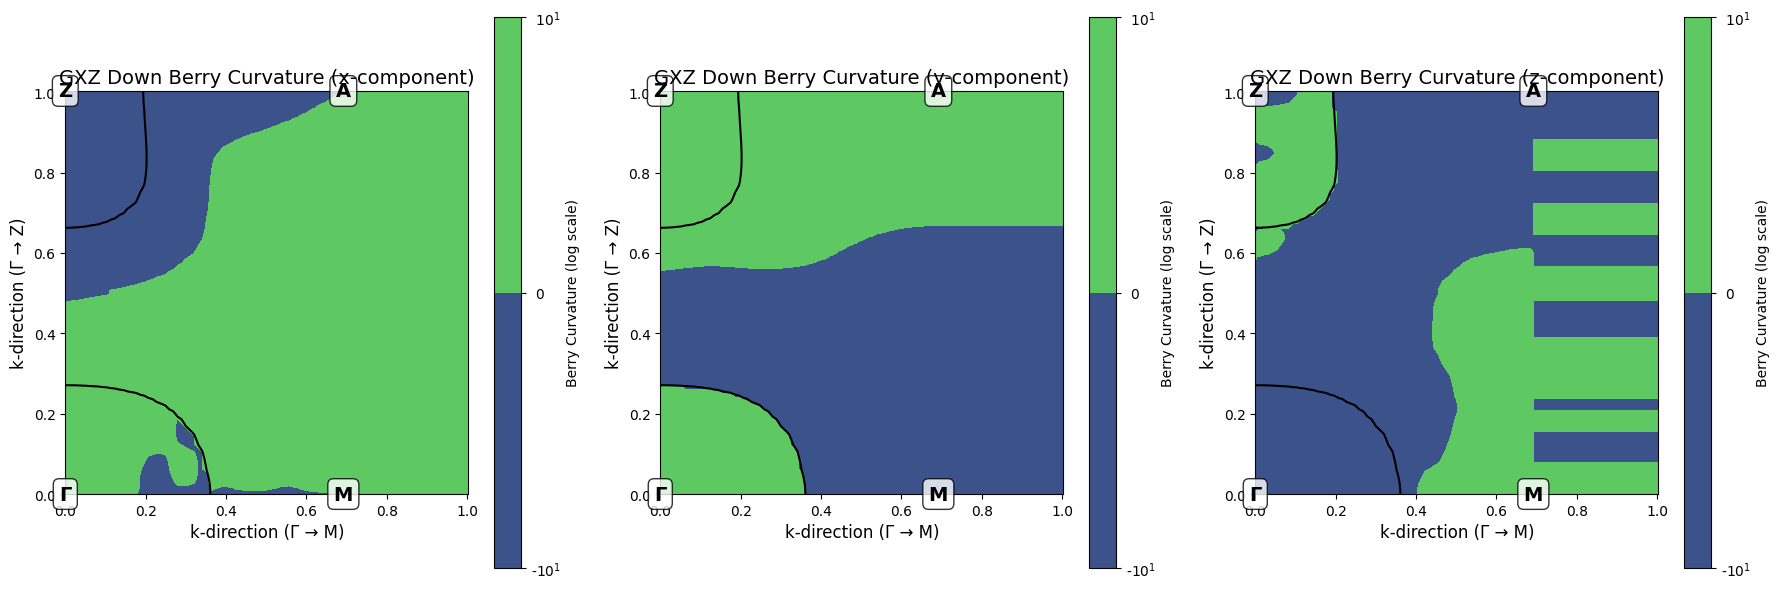

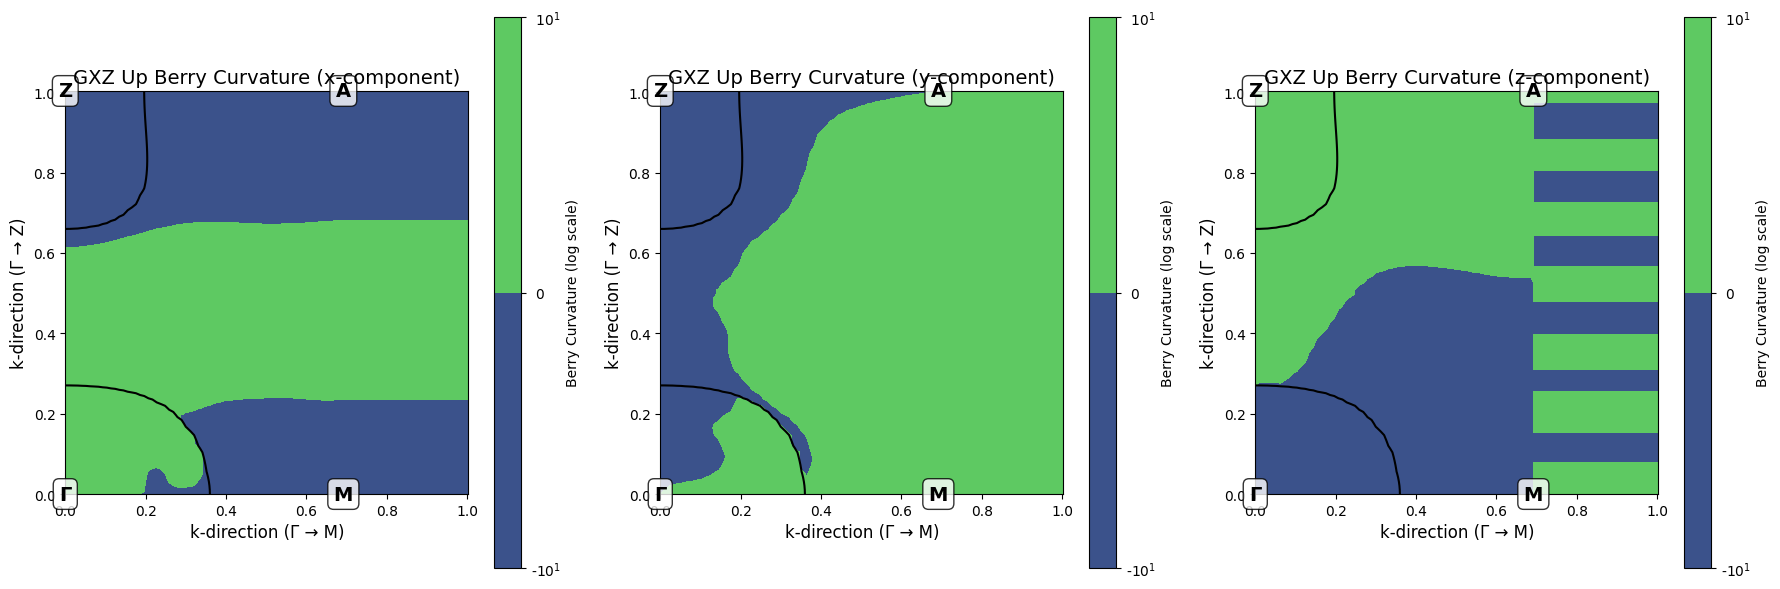

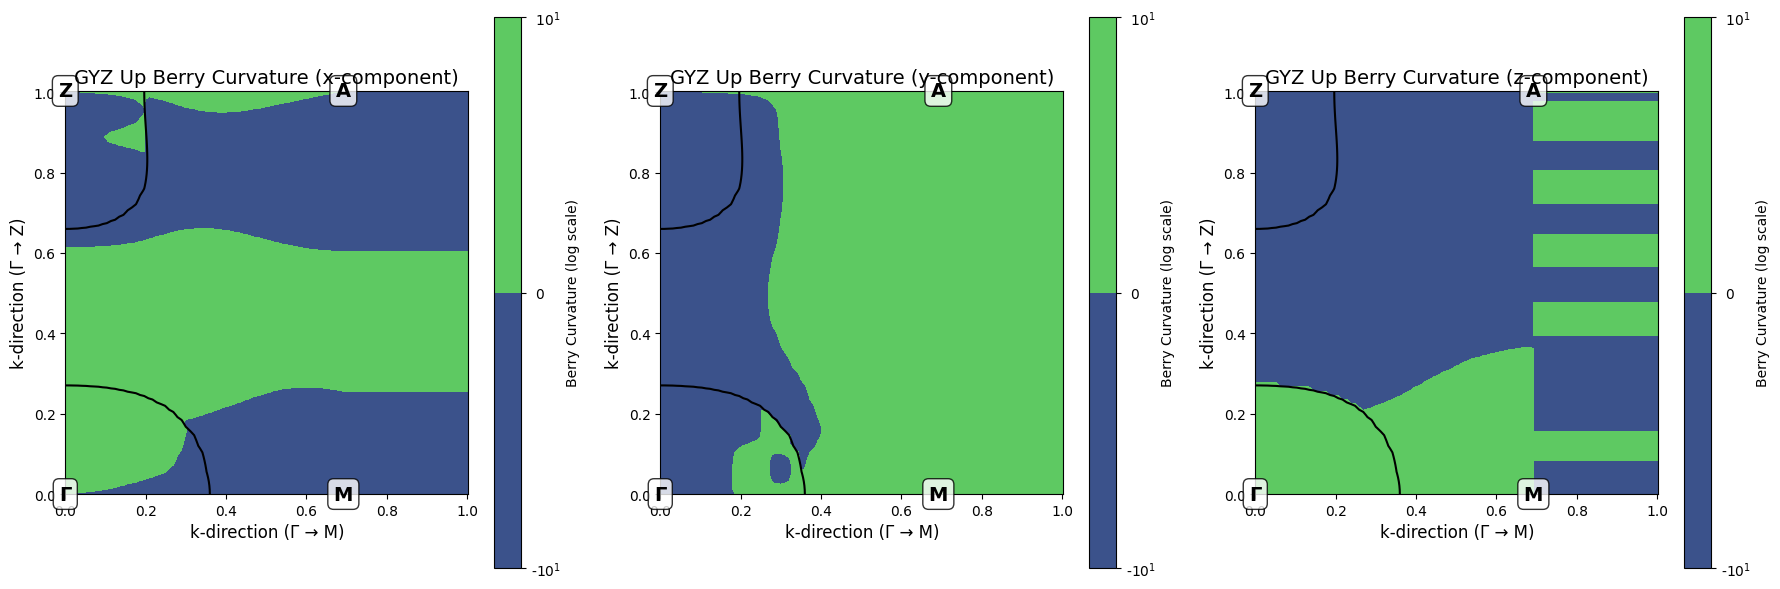

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate
from collections import OrderedDict

def create_heatmap_with_fermi_lines(data_path, title_prefix):
    """
    Create heatmap plots with Fermi lines for all Berry curvature components
    """
    # Load coordinate and curvature data
    points = np.loadtxt(f'{data_path}/RuO2-kslice-coord.dat')
    points_x = np.around(points[:,0], decimals=10)
    points_y = np.around(points[:,1], decimals=10)
    num_pt = len(points)
    
    # Load all Berry curvature components
    curv_data = np.loadtxt(f'{data_path}/RuO2-kslice-curv.dat')
    
    # Load bands data for Fermi lines
    bands = np.loadtxt(f'{data_path}/RuO2-kslice-bands.dat')
    numbands = bands.size // num_pt
    
    # Parameters from the original script
    area = 0.981404
    ef = 12.253400  # Fermi energy
    square = False
    
    # Setup interpolation grid
    if square:
        x_coord = list(OrderedDict.fromkeys(points_x))
        y_coord = list(OrderedDict.fromkeys(points_y))
        dimx = len(x_coord)
        dimy = len(y_coord)
    else:
        xmin, ymin = np.min(points_x), np.min(points_y)
        xmax, ymax = np.max(points_x), np.max(points_y)
        a = np.max(np.array([xmax-xmin, ymax-ymin]))
        num_int = int(round(np.sqrt(num_pt*a**2/area)))
        xint = np.linspace(xmin, xmin+a, num_int)
        yint = np.linspace(ymin, ymin+a, num_int)
        grid_x, grid_y = np.meshgrid(xint, yint)
    
    # Create figure with subplots for all three components
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    components = ['x', 'y', 'z']
    
    for i, comp_name in enumerate(components):
        ax = axes[i]
        
        # Get Berry curvature data for this component
        val = curv_data[:, i]
        
        # Apply logarithmic scaling as in original script
        val_log = np.array([np.log10(abs(elem))*np.sign(elem) if abs(elem)>10 else elem/10.0 for elem in val])
        
        # Create heatmap
        if square:
            Z = val_log.reshape(dimy, dimx)
            mn = int(np.floor(Z.min()))
            mx = int(np.ceil(Z.max()))
            ticks = range(mn, mx+1)
            contourf = ax.contourf(x_coord, y_coord, Z, ticks, origin='lower')
        else:
            valint = interpolate.griddata((points_x, points_y), val_log, (grid_x, grid_y), method='nearest')
            mn = int(np.floor(valint.min()))
            mx = int(np.ceil(valint.max()))
            ticks = range(mn, mx+1)
            contourf = ax.contourf(xint, yint, valint, ticks)
        
        # Add Fermi lines
        if square:
            bbands = bands.reshape((dimy, dimx, numbands))
            for j in range(numbands):
                Z_band = bbands[:,:,j]
                ax.contour(x_coord, y_coord, Z_band, [ef], colors='black', linewidths=1.5)
        else:
            bbands = bands.reshape((num_pt, numbands))
            for j in range(numbands):
                bandint = interpolate.griddata((points_x, points_y), bbands[:,j], (grid_x, grid_y), method='nearest')
                ax.contour(grid_x, grid_y, bandint, [ef], colors='black', linewidths=1.5)
        
        # Set labels and title
        ax.set_xlabel('k-direction (Γ → M)', fontsize=12)
        ax.set_ylabel('k-direction (Γ → Z)', fontsize=12)
        ax.set_title(f'{title_prefix} Berry Curvature ({comp_name}-component)', fontsize=14)
        
        # Add k-point labels if the range is large enough
        x_range = points_x.max() - points_x.min()
        y_range = points_y.max() - points_y.min()
        if x_range > 0.3 and y_range > 0.3:
            ax.text(points_x.min(), points_y.min(), 'Γ', fontsize=14, fontweight='bold',
                   ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            ax.text(points_x.max(), points_y.min(), 'M', fontsize=14, fontweight='bold',
                   ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            ax.text(points_x.min(), points_y.max(), 'Z', fontsize=14, fontweight='bold',
                   ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            ax.text(points_x.max(), points_y.max(), 'A', fontsize=14, fontweight='bold',
                   ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        # Create colorbar with proper tick labels
        ticklabels = []
        for n in ticks:
            if n < 0: 
                ticklabels.append(f'-$10^{{{abs(n)}}}$')
            elif n == 0:
                ticklabels.append(f' ${n}$')
            else:
                ticklabels.append(f' $10^{{{n}}}$')
        
        cbar = plt.colorbar(contourf, ax=ax)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels(ticklabels)
        cbar.set_label('Berry Curvature (log scale)', fontsize=10)
        
        ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

# Create plots for different data sets
print("Creating Berry curvature heatmaps with Fermi lines...")

# GMZ down data
fig1 = create_heatmap_with_fermi_lines('GMZ/down', 'GMZ Down')
plt.show()

# GMZ up data  
fig2 = create_heatmap_with_fermi_lines('GMZ/up', 'GMZ Up')
plt.show()

# GXZ down data
fig3 = create_heatmap_with_fermi_lines('GXZ/down', 'GXZ Down')
plt.show()

# GXZ up data
fig4 = create_heatmap_with_fermi_lines('GXZ/up', 'GXZ Up')
plt.show()

# GYZ up data (only up data available)
fig5 = create_heatmap_with_fermi_lines('GYZ/up', 'GYZ Up')
plt.show()